In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_excel(r"C:\Users\Samuel\Documents\Data_Analytics\data_clean.xlsx")

In [4]:
#Missing Value

df.isnull().sum()

Place_Id          0
Place_Name        0
Category          0
City              0
Price             0
Price_Category    0
User_Id           0
Place_Ratings     0
dtype: int64

In [5]:
#Cek Duplicate

df.duplicated().sum()

np.int64(0)

In [6]:
df["Price"].describe()

count      9921.000000
mean      23774.317105
std       62834.992319
min           0.000000
25%           0.000000
50%        5000.000000
75%       20000.000000
max      900000.000000
Name: Price, dtype: float64

### Feature Engineering: Rating Aggregation

Pada tahap ini dilakukan agregasi data berdasarkan Place_Id.
Nilai rata-rata rating (mean) digunakan sebagai fitur Avg_Rating untuk mengetahui
tingkat kepuasan rata-rata wisatawan terhadap suatu tempat.

Nilai standar deviasi (std) digunakan sebagai fitur Rating_STD untuk mengukur
variasi atau konsistensi pemberian rating oleh wisatawan.

In [ ]:
place_analysis = df.groupby('Place_Id').agg({
    'Place_Ratings':['mean','std'],
    'Category':'first',
    'City':'first',
    'Price':'first'
}).reset_index()

# Untuk rename hasil agregasi
# Place_Ratings_mean = Avg_Rating
# Place_Ratings_std  = Rating_STD

place_analysis.columns = [
    'Place_Id',
    'Avg_Rating',
    'Rating_STD',
    'Category',
    'City',
    'Price'
]

median_std = place_analysis['Rating_STD'].median()

place_analysis['Rating_Consistency'] = np.where(
    place_analysis['Rating_STD'] <= median_std,
    'Consistent',
    'Inconsistent'
)

In [8]:
place_analysis['Rating_Consistency'].value_counts()

Rating_Consistency
Consistent      219
Inconsistent    218
Name: count, dtype: int64

### descriptive analysis

In [23]:
descriptive = place_analysis['Avg_Rating'].describe()

print(descriptive)

count    437.000000
mean       3.068351
std        0.304438
min        2.062500
25%        2.880000
50%        3.076923
75%        3.272727
max        3.933333
Name: Avg_Rating, dtype: float64


### advanced analysis

In [9]:
city_category = place_analysis.groupby(
    ['City','Category']
)['Avg_Rating'].mean().reset_index()

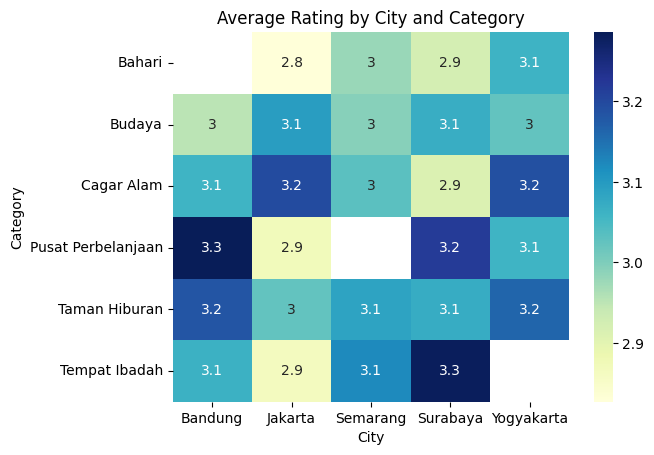

In [10]:
pivot_table = city_category.pivot(
    index='Category',
    columns='City',
    values='Avg_Rating'
)

sns.heatmap(
    pivot_table,
    annot=True,
    cmap='YlGnBu'
)

plt.title('Average Rating by City and Category')
plt.show()

Berdasarkan heatmap, rata-rata rating antar kombinasi kota dan kategori wisata berada pada rentang yang relatif seragam. Beberapa kombinasi seperti Bandung - Pusat Perbelanjaan dan Surabaya - Tempat Ibadah menunjukkan rating yang lebih tinggi dibanding kombinasi lainnya, namun selisihnya tidak terlalu besar.

### EDA

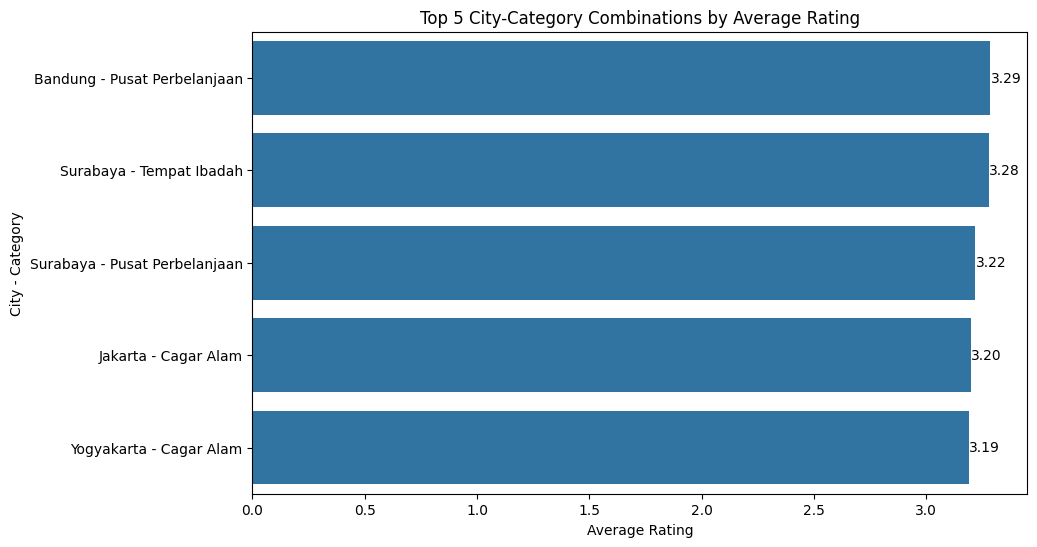

In [21]:
top5 = city_category.nlargest(5, 'Avg_Rating').copy()

top5['Combination'] = (
    top5['City'] + ' - ' + top5['Category']
)


plt.figure(figsize=(10,6))

sns.barplot(
    data=top5,
    x='Avg_Rating',
    y='Combination'
)

plt.title('Top 5 City-Category Combinations by Average Rating')
plt.xlabel('Average Rating')
plt.ylabel('City - Category')

for i, value in enumerate(top5['Avg_Rating']):
    plt.text(
        value,
        i,
        f'{value:.2f}',
        va='center'
    )

plt.show()

Berdasarkan visualisasi Top 5 City-Category Combination, kombinasi Bandung - Pusat Perbelanjaan memperoleh rata-rata rating tertinggi sebesar 3.29, diikuti Surabaya - Tempat Ibadah

Tempat Ibadah sebesar 3.28. Hasil ini menunjukkan bahwa beberapa kombinasi kota dan kategori wisata memiliki tingkat kepuasan wisatawan yang lebih tinggi dibanding kombinasi lainnya.

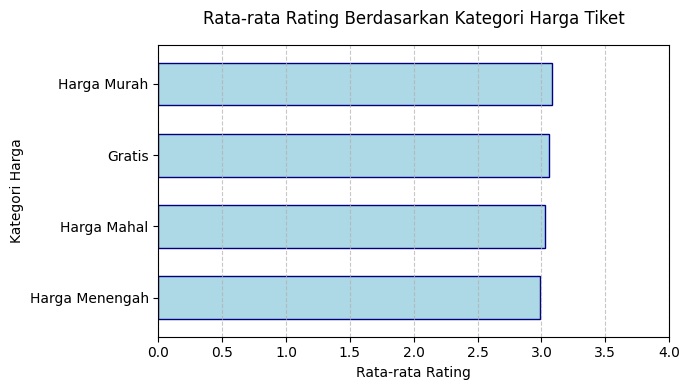

In [13]:
price_correlation = df.groupby('Price_Category')['Place_Ratings'].mean().sort_values()

plt.figure(figsize=(7, 4))
price_correlation.plot(kind='barh', color='lightblue', edgecolor='navy', width=0.6)

plt.title('Rata-rata Rating Berdasarkan Kategori Harga Tiket', fontsize=12, pad=15)
plt.xlabel('Rata-rata Rating')
plt.ylabel('Kategori Harga')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.xlim(0, 4) 

plt.tight_layout()
plt.show()

Kategori Harga Murah memiliki rata-rata rating tertinggi, sedangkan Harga Menengah memiliki rata-rata rating terendah. Namun perbedaan antar kategori harga tidak terlalu besar.

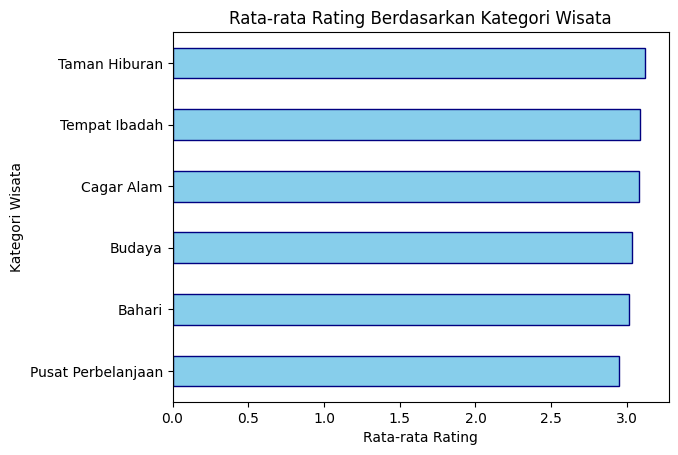

In [14]:
category_rating = df.groupby("Category")["Place_Ratings"].mean().sort_values(ascending=True)

category_rating.plot(kind="barh", color='skyblue', edgecolor='navy')

plt.title("Rata-rata Rating Berdasarkan Kategori Wisata")
plt.xlabel("Rata-rata Rating")
plt.ylabel("Kategori Wisata")

plt.show()

Kategori Taman Hiburan memiliki rata-rata rating tertinggi sebesar 3.12, sedangkan Pusat Perbelanjaan memiliki rata-rata rating terendah sebesar 2.95. Namun, selisih rating antar kategori relatif kecil.

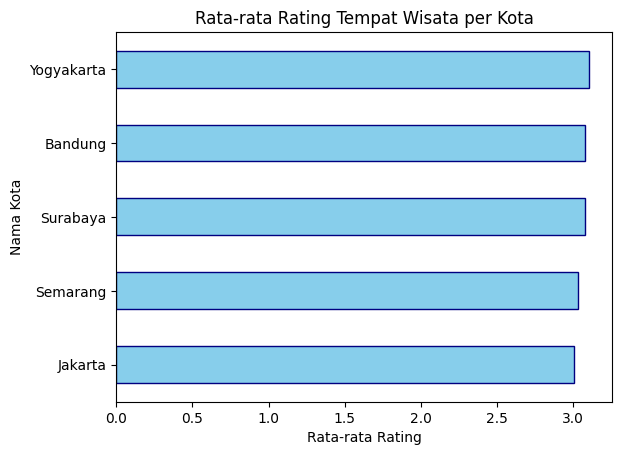

In [15]:
city_rating = df.groupby("City")["Place_Ratings"].mean().sort_values(ascending=True)

city_rating.plot(kind="barh", color='skyblue', edgecolor='navy')

plt.title("Rata-rata Rating Tempat Wisata per Kota")
plt.xlabel("Rata-rata Rating")
plt.ylabel("Nama Kota")

plt.show()

Yogyakarta memiliki rata-rata rating tertinggi sebesar 3.10, sedangkan Jakarta memiliki rata-rata rating terendah sebesar 3.01. Perbedaan antar kota terlihat relatif kecil.

### Correlation Analysis


In [ ]:
corr_data = place_analysis[
    ['Avg_Rating','Price','Rating_STD']
]

corr_matrix = corr_data.corr()

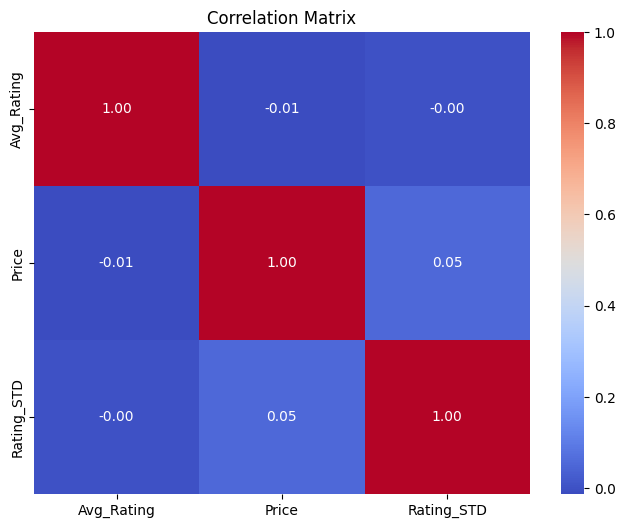

In [17]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')
plt.show()

Berdasarkan correlation matrix, tidak ditemukan hubungan linear yang kuat antar variabel yang dianalisis. Korelasi antara Avg_Rating dan Price sebesar -0.01 menunjukkan bahwa harga destinasi wisata tidak memiliki hubungan yang signifikan dengan rata-rata rating yang diberikan wisatawan. Selain itu, korelasi antara Avg_Rating dan Rating_STD yang mendekati nol menunjukkan bahwa konsistensi rating tidak berkaitan langsung dengan tingkat rating rata-rata. Hasil ini mengindikasikan bahwa faktor harga maupun variasi rating bukan merupakan penentu utama terhadap rata-rata rating destinasi wisata pada dataset ini.

### Best and Worst Performing City-Category Combination

In [18]:
highest = city_category.loc[
    city_category['Avg_Rating'].idxmax()
]

lowest = city_category.loc[
    city_category['Avg_Rating'].idxmin()
]

print("Highest Combination")
print(highest)

print("\nLowest Combination")
print(lowest)

Highest Combination
City                     Bandung
Category      Pusat Perbelanjaan
Avg_Rating              3.285714
Name: 2, dtype: object

Lowest Combination
City           Jakarta
Category        Bahari
Avg_Rating    2.827119
Name: 5, dtype: object


### Hypothesis Testing

H0 : Tidak terdapat perbedaan rata-rata rating antar kategori wisata.

H1 : Terdapat perbedaan rata-rata rating antar kategori wisata.

In [24]:
from scipy.stats import f_oneway

groups = [
    group['Place_Ratings'].values
    for _, group in df.groupby('Category')
]

f_stat, p_value = f_oneway(*groups)

print("F-Statistic :", f_stat)
print("P-Value :", p_value)

F-Statistic : 2.1660806571510838
P-Value : 0.05493840349561335


In [25]:
alpha = 0.05

if p_value < alpha:
    print("\nKeputusan: Tolak H0")
    print("Kesimpulan: Terdapat perbedaan rata-rata rating yang signifikan antar kategori wisata.")
else:
    print("\nKeputusan: Gagal Menolak H0")
    print("Kesimpulan: Tidak terdapat perbedaan rata-rata rating yang signifikan antar kategori wisata.")


Keputusan: Gagal Menolak H0
Kesimpulan: Tidak terdapat perbedaan rata-rata rating yang signifikan antar kategori wisata.


Berdasarkan hasil uji hipotesis, diperoleh nilai p-value sebesar 0.0549, yang lebih besar dari tingkat signifikansi 0.05. Oleh karena itu, H0 gagal ditolak. Hasil ini menunjukkan bahwa tidak terdapat perbedaan rata-rata rating yang signifikan antar kategori wisata. Meskipun terdapat perbedaan nilai rata-rata pada analisis sebelumnya, perbedaan tersebut belum cukup kuat secara statistik untuk dianggap signifikan.